<a href="https://colab.research.google.com/github/doradosanti/myProjects/blob/main/DT%2CKNN%2CNBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Business Understanding:

Voting behavior refers to why people vote the way they do which is influenced by a mix of personal, social, and political factors. Analyzing voting behavior helps understand public opinion trends and decision making processes across groups.
Voting behavior is difficult to predict and it affects many industries, so in this assignment we are analyzing demographic, social, and economic data to uncover patterns in voting behavior. Voting behavior influences industries primarily through shifts resource allocation, regulations, and consumer sentiment. Many industries can benefit from having a predicitive model such as marketing firms to improve forecast accuracy. Additionally, financial firms can also benefit as they can anticipate impacts on markets after elections.


#Data Understanding


##VARIABLE DESCRIPTIONS:


*   Ballot Type: This is a binary nominal variable indicating the type of ballot measure being voted on. (1= Gambling, 2 = Wagering)
*   Population : numeric variable of total county population.
*   PCI (per capita income): numeric variable that reflects economic conditions.
*   Medium family income: numeric variable that reflects economic status
*   Population density (total pop. / total land area): a numeric measure of how many people live in a given area
*   Size of county (sq.mile): this numeric variable helps derive density
*   MSA (Metropolitan Statistical Area): Binary categorical variable that reflects if county is either rural or urban
*   Percent black/white: numerical variable depicting racial composition.
*   Percent female/male: numerical variable depicting gender distribution. another demographic characteristic
*   Poverty level: numerical variable that also reflects economic conditions
*   NO of churches: numerical variable that reflects religious presence.




















All the socieconomic, demographic, and geographic variables describe factors that could influence voting outcomes. Religion can inlfuence moral or social opinions so religous variables may predict more conservative voting. Age and race provide insight into cultural or generational trends. Urban vs rural areas often differ in voting. PCI and Poverty level may also affect public opinion.

Target Variable: Dependent variable
Type: Binary nominal
This variable indicates whether a ballot passed in a county (1 = Yes, 0 = No)

## Can other existing variables help build meaningful and predictive classification model for this target variable? Can we use all of them as predictors?
To avoid data leakage it is important to remove highly correlated variables such as 'percent male' and 'percent female' and using 'For' and 'Against' or 'total caste' as they directly reflect voting results which could cause data leakage.

#Data Preperation

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing

In [ ]:
# Read data
gamingData = pd.read_excel("/content/drive/MyDrive/IS470_data/Gaming Ballot Dataset.xls")
gamingData

,State No,County No,FOR,AGAINST,TOTAL CASTE,DEPENDENT VARIABLE,BALLOT TYPE,POPULATION,PCI,MEDIUM FAMILY INCOME,...,UNEMPLOYMENT RATE,AGE LESS THAN 18,AGE24,AGE44,AGE64,AGE OLDER THAN 65,MSA,PERCENT MINORITY,NO OF OLDER,NO OF YOUNGER
0,1,1,42385,22992,65377,1,1,265038,15607,34618,...,5.0,80600,22627,94724,46933,20154,1,0.25,67087,189448
1,1,2,2015,1852,3867,1,1,13617,13740,23114,...,7.0,4285,1861,4092,2114,1265,2,0.40,3379,8184
2,1,3,51959,48406,100365,1,1,391511,24187,44874,...,3.0,111243,29574,150740,70783,29171,1,0.15,99954,301480
3,1,4,957,856,1813,1,1,5345,12816,27359,...,5.0,1647,229,1670,1178,621,2,0.26,1799,3340
4,1,5,942,1129,2071,0,1,4556,19017,23054,...,1.0,1192,220,1231,973,940,2,0.07,1913,2462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,18,41,44069,27316,71385,1,1,354527,18893,27622,...,15.6,124607,30781,100927,62657,35555,1,0.50,98212,201854
1283,18,42,10026,9755,19781,1,1,53029,20082,33810,...,8.0,11972,3497,16099,12015,9446,2,0.13,21461,32198
1284,18,43,126397,76905,203302,1,1,732143,28711,49763,...,5.6,208062,65744,235177,146412,76748,1,0.38,223160,470354
1285,18,44,26412,23464,49876,1,1,153293,25791,38751,...,5.4,39727,23948,46570,27627,15421,1,0.35,43048,93140


State No and County No are unique identifiers and will not be used in the modeling. The dataset contains 1,287 counties across multiple states. Each record represents one county level vote on a ballot

In [ ]:
gamingData.keys()

Index(['State No', 'County No', 'FOR', 'AGAINST', 'TOTAL CASTE',
       'DEPENDENT VARIABLE', 'BALLOT TYPE', 'POPULATION', 'PCI',
       'MEDIUM FAMILY INCOME', 'SIZE OF COUNTY', 'POPULATION DENSITY',
       'PERCENT WHITE', 'PERCENT BLACK', 'PERCENT OTHER', 'PERCENT MALE',
       'PERCENT FEMALE', 'NO OF CHURCHES', 'NO OF CHURCH MEMBERS',
       'PERCENT CHURCH MEMBERS OF POPULATION', 'POVERTY LEVEL',
       'UNEMPLOYMENT RATE', 'AGE LESS THAN 18', 'AGE24', 'AGE44', 'AGE64',
       'AGE OLDER THAN 65', 'MSA', 'PERCENT MINORITY', 'NO OF OLDER',
       'NO OF YOUNGER'],
      dtype='object')

In [ ]:
# Select the desired columns only
desired_columns = ['DEPENDENT VARIABLE', 'BALLOT TYPE', 'POPULATION', 'PCI', 'MEDIUM FAMILY INCOME','SIZE OF COUNTY', 'POPULATION DENSITY','PERCENT WHITE', 'PERCENT MALE', 'NO OF CHURCHES','POVERTY LEVEL','UNEMPLOYMENT RATE', 'AGE64', 'PERCENT FEMALE',
'AGE24', 'MSA']
gaming_ballot_desired = gamingData [desired_columns]

In [ ]:
# Replacing 1 with Yes and 0 with No in the target column DEPENDENT VARIABLE
gamingData = gaming_ballot_desired.copy()
gamingData.loc[:, 'DEPENDENT VARIABLE'] = gamingData['DEPENDENT VARIABLE'].replace({0: 'No', 1: 'Yes'})

/tmp/ipython-input-1615181617.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Yes' 'Yes' 'Yes' ... 'Yes' 'Yes' 'Yes']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gamingData.loc[:, 'DEPENDENT VARIABLE'] = gamingData['DEPENDENT VARIABLE'].replace({0: 'No', 1: 'Yes'})


In [ ]:
#head rows of a data frame
gamingData.head()

,DEPENDENT VARIABLE,BALLOT TYPE,POPULATION,PCI,MEDIUM FAMILY INCOME,SIZE OF COUNTY,POPULATION DENSITY,PERCENT WHITE,PERCENT MALE,NO OF CHURCHES,POVERTY LEVEL,UNEMPLOYMENT RATE,AGE64,PERCENT FEMALE,AGE24,MSA
0,Yes,1,265038,15607,34618,1192.0,223.29,0.75,0.496,128,10.4,5.0,46933,0.504,22627,1
1,Yes,1,13617,13740,23114,722.8,18.81,0.59,0.491,22,24.8,7.0,2114,0.509,1861,2
2,Yes,1,391511,24187,44874,803.2,490.34,0.85,0.488,180,5.9,3.0,70783,0.512,29574,1
3,Yes,1,5345,12816,27359,1349.4,3.99,0.74,0.510,14,16.9,5.0,1178,0.490,229,2
4,No,1,4556,19017,23054,2555.9,1.77,0.93,0.495,23,19.0,1.0,973,0.505,220,2


In [ ]:
#tail rows of a data frame
gamingData.tail()

,DEPENDENT VARIABLE,BALLOT TYPE,POPULATION,PCI,MEDIUM FAMILY INCOME,SIZE OF COUNTY,POPULATION DENSITY,PERCENT WHITE,PERCENT MALE,NO OF CHURCHES,POVERTY LEVEL,UNEMPLOYMENT RATE,AGE64,PERCENT FEMALE,AGE24,MSA
1282,Yes,1,354527,18893,27622,4839.4,74.68,0.49,0.498304,301,27.9,15.6,62657,0.501696,30781,1
1283,Yes,1,53029,20082,33810,2274.5,23.17,0.87,0.525548,40,14.8,8.0,12015,0.474452,3497,2
1284,Yes,1,732143,28711,49763,2208.4,334.27,0.62,0.505349,313,10.3,5.6,146412,0.494651,65744,1
1285,Yes,1,153293,25791,38751,1022.9,152.51,0.65,0.496522,80,15.8,5.4,27627,0.503478,23948,1
1286,Yes,1,59953,16405,26842,643.6,93.69,0.70,0.497523,50,25.5,13.5,11403,0.502477,5315,1


In [ ]:
# Examine missing values
gamingData.isnull().sum()

,0
DEPENDENT VARIABLE,0
BALLOT TYPE,0
POPULATION,0
PCI,0
MEDIUM FAMILY INCOME,0
SIZE OF COUNTY,0
POPULATION DENSITY,0
PERCENT WHITE,0
PERCENT MALE,0
NO OF CHURCHES,0


In [ ]:
# Set missing values as none
gamingData = gamingData.dropna()

In [ ]:
# Examine missing values again
gamingData.isnull().sum()

,0
DEPENDENT VARIABLE,0
BALLOT TYPE,0
POPULATION,0
PCI,0
MEDIUM FAMILY INCOME,0
SIZE OF COUNTY,0
POPULATION DENSITY,0
PERCENT WHITE,0
PERCENT MALE,0
NO OF CHURCHES,0


In [ ]:
# Examine variable type
gamingData.dtypes

,0
DEPENDENT VARIABLE,object
BALLOT TYPE,int64
POPULATION,int64
PCI,int64
MEDIUM FAMILY INCOME,int64
SIZE OF COUNTY,float64
POPULATION DENSITY,float64
PERCENT WHITE,float64
PERCENT MALE,float64
NO OF CHURCHES,int64


In [ ]:
# Change categorical variables to "category"
gamingData['DEPENDENT VARIABLE'] = gamingData['DEPENDENT VARIABLE'].astype('category')
gamingData['BALLOT TYPE'] = gamingData['BALLOT TYPE'].astype('category')
gamingData['MSA'] = gamingData['MSA'].astype('category')

In [ ]:
# Display all numeric variables
gamingData.select_dtypes(include=['number'])

,POPULATION,PCI,MEDIUM FAMILY INCOME,SIZE OF COUNTY,POPULATION DENSITY,PERCENT WHITE,PERCENT MALE,NO OF CHURCHES,POVERTY LEVEL,UNEMPLOYMENT RATE,AGE64,PERCENT FEMALE,AGE24
0,265038,15607,34618,1192.0,223.29,0.75,0.496000,128,10.4,5.0,46933,0.504000,22627
1,13617,13740,23114,722.8,18.81,0.59,0.491000,22,24.8,7.0,2114,0.509000,1861
2,391511,24187,44874,803.2,490.34,0.85,0.488000,180,5.9,3.0,70783,0.512000,29574
3,5345,12816,27359,1349.4,3.99,0.74,0.510000,14,16.9,5.0,1178,0.490000,229
4,4556,19017,23054,2555.9,1.77,0.93,0.495000,23,19.0,1.0,973,0.505000,220
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,354527,18893,27622,4839.4,74.68,0.49,0.498304,301,27.9,15.6,62657,0.501696,30781
1283,53029,20082,33810,2274.5,23.17,0.87,0.525548,40,14.8,8.0,12015,0.474452,3497
1284,732143,28711,49763,2208.4,334.27,0.62,0.505349,313,10.3,5.6,146412,0.494651,65744
1285,153293,25791,38751,1022.9,152.51,0.65,0.496522,80,15.8,5.4,27627,0.503478,23948


In [ ]:
# Display all categorical variables
gamingData.select_dtypes(include=['category'])

,DEPENDENT VARIABLE,BALLOT TYPE,MSA
0,Yes,1,1
1,Yes,1,2
2,Yes,1,1
3,Yes,1,2
4,No,1,2
...,...,...,...
1282,Yes,1,1
1283,Yes,1,2
1284,Yes,1,1
1285,Yes,1,1


In [ ]:
# Show the statistics of a numeric variable
gamingData['POPULATION'].describe()

,POPULATION
count,1.287000e+03
mean,5.247528e+04
std,1.097376e+05
min,3.270000e+02
25%,6.541500e+03
50%,1.612600e+04
75%,4.313700e+04
max,1.206243e+06


Standard deviation suggests population varies widely. There is one rural area with 327 people. And one urban area with about 1 million pop. Population is highly skewed to the right (most are small)

In [ ]:
# Show the statistics of two numeric variables
gamingData[['PCI','MEDIUM FAMILY INCOME']].describe()

,PCI,MEDIUM FAMILY INCOME
count,1287.000000,1287.000000
mean,16652.771562,27398.725719
std,3827.951391,6403.965308
min,5720.000000,12225.000000
25%,14204.000000,22907.000000
50%,16177.000000,26508.000000
75%,18582.500000,31060.500000
max,44518.000000,55643.000000


The mean and median are close are close for both variables. The mean PCI and medium family income are lower to middle income (16,000 and 27,000)

In [ ]:
# Obtain the variance, standard deviation, and range of a numeric varaible: Attack
print("variance: ", gamingData['NO OF CHURCHES'].var(), "standard deviation: ", gamingData['NO OF CHURCHES'].std(), "range: ", gamingData['NO OF CHURCHES'].min(), gamingData['NO OF CHURCHES'].max())

variance:  4687.732983622568 standard deviation:  68.46702113881229 range:  1 738


The standard deviation and range indicates that number of churches varies across counties

In [ ]:
# Generate the correlation matrix of numeric variables
gamingData[['PCI','MEDIUM FAMILY INCOME','POVERTY LEVEL','UNEMPLOYMENT RATE','POPULATION DENSITY','SIZE OF COUNTY','PERCENT WHITE', 'AGE24']].corr()

,PCI,MEDIUM FAMILY INCOME,POVERTY LEVEL,UNEMPLOYMENT RATE,POPULATION DENSITY,SIZE OF COUNTY,PERCENT WHITE,AGE24
PCI,1.000000,0.718365,-0.601803,-0.244961,0.371657,0.021308,0.347894,0.328924
MEDIUM FAMILY INCOME,0.718365,1.000000,-0.725819,-0.238295,0.322424,-0.003760,0.348002,0.332224
POVERTY LEVEL,-0.601803,-0.725819,1.000000,0.551619,-0.101208,0.079614,-0.763003,-0.071449
UNEMPLOYMENT RATE,-0.244961,-0.238295,0.551619,1.000000,0.006384,0.090892,-0.540315,0.063859
POPULATION DENSITY,0.371657,0.322424,-0.101208,0.006384,1.000000,-0.167920,-0.112943,0.681265
SIZE OF COUNTY,0.021308,-0.003760,0.079614,0.090892,-0.167920,1.000000,-0.076461,0.054009
PERCENT WHITE,0.347894,0.348002,-0.763003,-0.540315,-0.112943,-0.076461,1.000000,-0.156386
AGE24,0.328924,0.332224,-0.071449,0.063859,0.681265,0.054009,-0.156386,1.000000




*   income, poverty, and unemployment variables are highly correlated
*   Population density and age are positively correlated
*   Percent white is negatively correlated with poverty






#10 Charts

Text(0.5, 1.0, 'countplot of Dependent Variable')

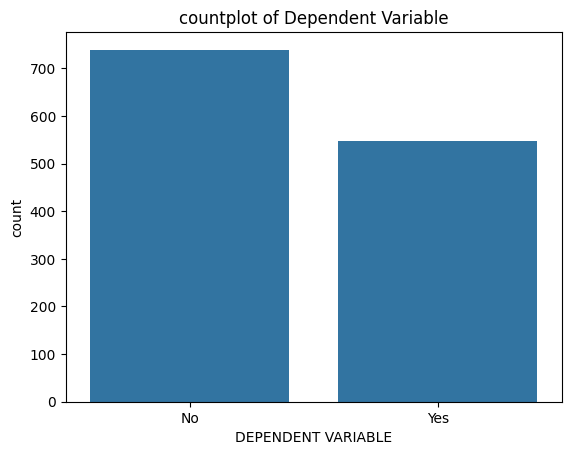

In [ ]:
# Plot of categorical variable
snsplot = sns.countplot(x='DEPENDENT VARIABLE', data=gamingData)
snsplot.set_title("countplot of Dependent Variable")

More counties voted no than yes.

Text(0.5, 1.0, 'countplot of Ballot type Variable')

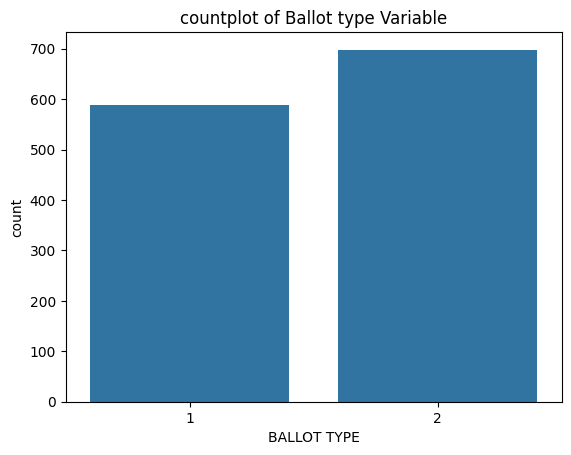

In [ ]:
# Plot of categorical variable
snsplot = sns.countplot(x='BALLOT TYPE', data=gamingData)
snsplot.set_title("countplot of Ballot type Variable")

Slightly more wagering ballots

Text(0, 0.5, 'Count')

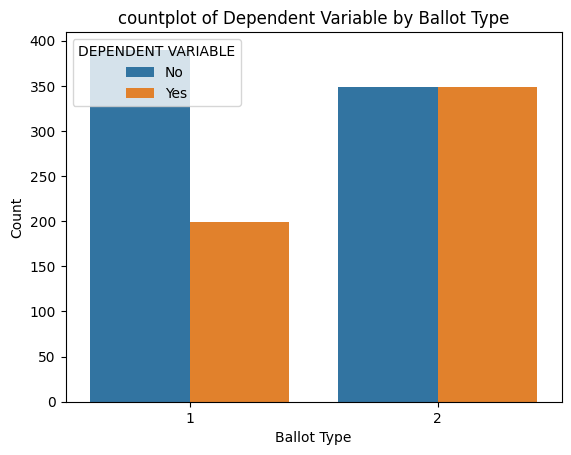

In [ ]:
#Grouped Chart of Ballot type and dependent variable
snsplot = sns.countplot(x='BALLOT TYPE', hue='DEPENDENT VARIABLE', data=gamingData)
snsplot.set_title("countplot of Dependent Variable by Ballot Type")
plt.xlabel('Ballot Type')
plt.ylabel('Count')

Public opinion on wagering is even. More opposition towards gambling ballots

Text(0.5, 1.0, 'Histogram of Percent White')

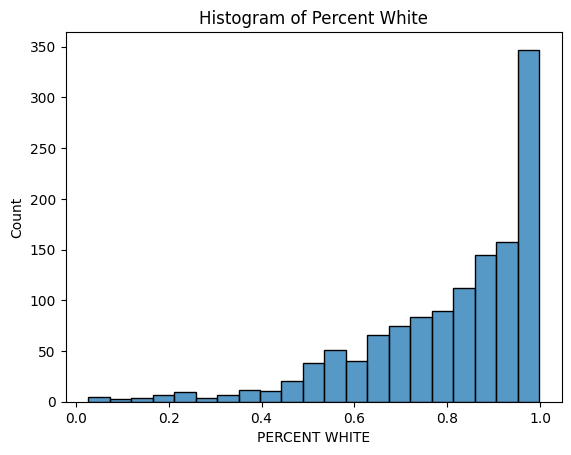

In [ ]:
# Histogram of a numeric variable
snsplot = sns.histplot(x='PERCENT WHITE', data = gamingData)
snsplot.set_title("Histogram of Percent White")

High percent of white residents in many counties

Text(0.5, 1.0, 'Histogram of MEDIUM FAMILY INCOME')

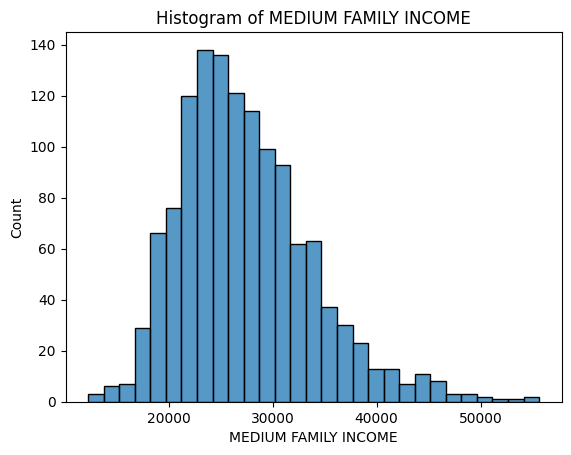

In [ ]:
# Histogram of a numeric variable
snsplot = sns.histplot(x='MEDIUM FAMILY INCOME', data = gamingData)
snsplot.set_title("Histogram of MEDIUM FAMILY INCOME")

small right skew. Most counties centered within 20k and about 27k

Text(0.5, 1.0, 'Boxplot of POVERTY LEVEL')

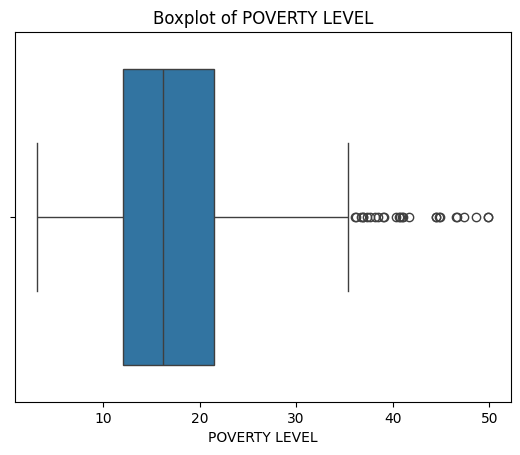

In [ ]:
# Boxplot of a numeric variable
snsplot = sns.boxplot(x='POVERTY LEVEL', data = gamingData)
snsplot.set_title("Boxplot of POVERTY LEVEL")

There are several outliers above 35% extending to 50% (counties where poverty is extremely high).

Text(0.5, 1.0, 'Boxplot of Age Group 64 by Dependent Variable')

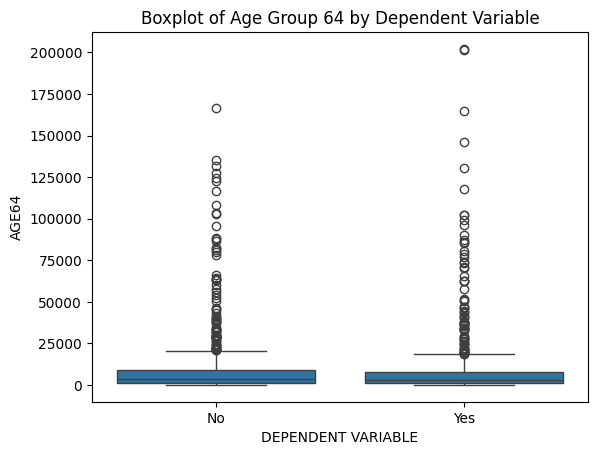

In [ ]:
#Chart of age group by Dependent variable
snsplot = sns.boxplot(x='DEPENDENT VARIABLE', y='AGE64', data = gamingData)
snsplot.set_title("Boxplot of Age Group 64 by Dependent Variable")

The two plots are similar in shape and spread, several outliers possibly more populated areas

Text(0.5, 1.0, 'Boxplot of Percent Female by Dependent Variable')

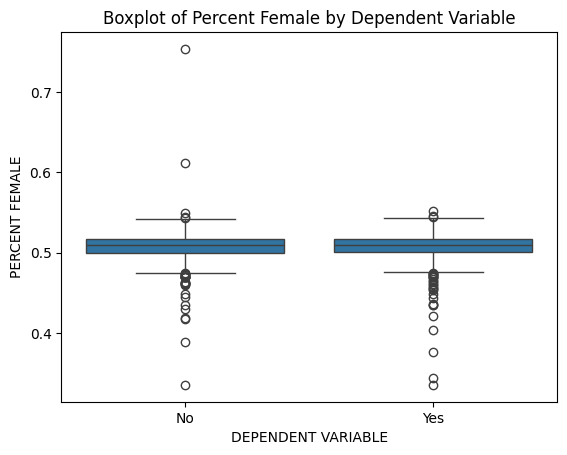

In [ ]:
#Boxplot of Percent Female by Dependent Variable
snsplot = sns.boxplot(x='DEPENDENT VARIABLE', y='PERCENT FEMALE', data=gamingData)
snsplot.set_title("Boxplot of Percent Female by Dependent Variable")

both yes and no have similar means and spread, few outliers with higher percent of females, overall weak predictor

Text(0.5, 1.0, 'Scatterplot of PCI vs POPULATION DENSITY')

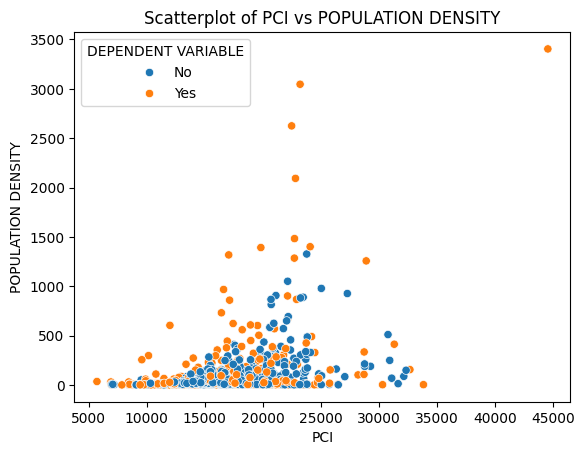

In [ ]:
# scatter plot of two numeric variables
snsplot = sns.scatterplot(x='PCI', y= 'POPULATION DENSITY', hue='DEPENDENT VARIABLE', data=gamingData)
snsplot.set_title("Scatterplot of PCI vs POPULATION DENSITY")

Counties with higher pop have more yes dots.

Text(0.5, 1.0, 'Scatterplot of unemployment rate vs Percent white')

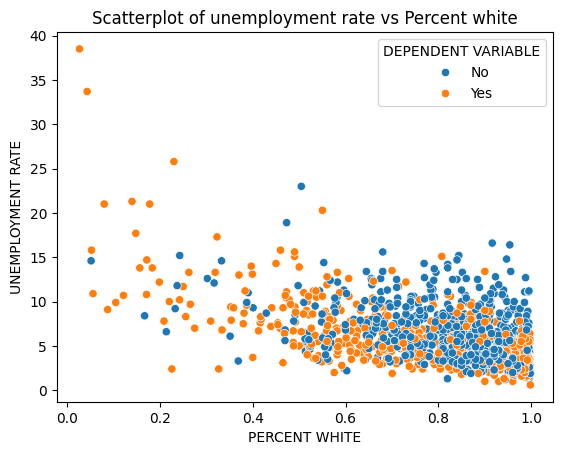

In [ ]:
#Scatterplot of unemployment rate vs Percent white
snsplot = sns.scatterplot(y='UNEMPLOYMENT RATE', x= 'PERCENT WHITE', hue='DEPENDENT VARIABLE', data=gamingData)
snsplot.set_title("Scatterplot of unemployment rate vs Percent white")

Most counties are predominately white, when percent white increases no votes are common

#Data Preperation Part 2

In [ ]:
# Create dummy variables
gamingData = pd.get_dummies(gamingData, columns=['BALLOT TYPE','MSA'], drop_first=True)
gamingData

,DEPENDENT VARIABLE,POPULATION,PCI,MEDIUM FAMILY INCOME,SIZE OF COUNTY,POPULATION DENSITY,PERCENT WHITE,PERCENT MALE,NO OF CHURCHES,POVERTY LEVEL,UNEMPLOYMENT RATE,AGE64,PERCENT FEMALE,AGE24,BALLOT TYPE_2,MSA_2
0,Yes,265038,15607,34618,1192.0,223.29,0.75,0.496000,128,10.4,5.0,46933,0.504000,22627,False,False
1,Yes,13617,13740,23114,722.8,18.81,0.59,0.491000,22,24.8,7.0,2114,0.509000,1861,False,True
2,Yes,391511,24187,44874,803.2,490.34,0.85,0.488000,180,5.9,3.0,70783,0.512000,29574,False,False
3,Yes,5345,12816,27359,1349.4,3.99,0.74,0.510000,14,16.9,5.0,1178,0.490000,229,False,True
4,No,4556,19017,23054,2555.9,1.77,0.93,0.495000,23,19.0,1.0,973,0.505000,220,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,Yes,354527,18893,27622,4839.4,74.68,0.49,0.498304,301,27.9,15.6,62657,0.501696,30781,False,False
1283,Yes,53029,20082,33810,2274.5,23.17,0.87,0.525548,40,14.8,8.0,12015,0.474452,3497,False,True
1284,Yes,732143,28711,49763,2208.4,334.27,0.62,0.505349,313,10.3,5.6,146412,0.494651,65744,False,False
1285,Yes,153293,25791,38751,1022.9,152.51,0.65,0.496522,80,15.8,5.4,27627,0.503478,23948,False,False


##Is the data balanced?

In [ ]:
# Examine the porportion of target variable for data set
target = gamingData['DEPENDENT VARIABLE']
print(target.value_counts(normalize=True))

DEPENDENT VARIABLE
No     0.574204
Yes    0.425796
Name: proportion, dtype: float64


Slighty imbalaned. Data needs to be rebalanced to learn from both outcomes fairly

#Modeling

##Decision Tree

In [ ]:
# Partition the data
predictors = gamingData.drop(['DEPENDENT VARIABLE'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(900, 15) (387, 15) (900,) (387,)


In [ ]:
# Taking steps to balance the train data
# Combine predictors_train and target_train into a single DataFrame
combined_train_df = pd.concat([predictors_train, target_train], axis=1)

# Separate majority and minority classes
majority_df = combined_train_df[combined_train_df['DEPENDENT VARIABLE'] == 'No']
minority_df = combined_train_df[combined_train_df['DEPENDENT VARIABLE'] == 'Yes']

# Undersample the majority class randomly
undersampled_majority = majority_df.sample(n=len(minority_df), random_state=5)

# Combine the undersampled majority class and the minority class
undersampled_data = pd.concat([undersampled_majority, minority_df])

# Shuffle the combined DataFrame to ensure randomness
balanced_data = undersampled_data.sample(frac=1, random_state=5)

# Split the balanced_data into predictors_train and target_train
predictors_train = balanced_data.drop(columns=['DEPENDENT VARIABLE'])
target_train = balanced_data['DEPENDENT VARIABLE']

In [ ]:
# Examine the porportion of target variable for train set
print(target_train.value_counts(normalize=True), target_train.shape)

DEPENDENT VARIABLE
No     0.5
Yes    0.5
Name: proportion, dtype: float64 (742,)


In [ ]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

DEPENDENT VARIABLE
No     0.542636
Yes    0.457364
Name: proportion, dtype: float64


###Max Depth = 2

In [ ]:
# Build a decision tree model on training data with max_depth = 2
model_tree1 = DecisionTreeClassifier(criterion = "entropy",random_state = 1, max_depth = 2)
model_tree1.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=1)

[Text(0.5, 0.8333333333333334, 'PERCENT WHITE <= 0.644\nentropy = 1.0\nsamples = 742\nvalue = [371, 371]\nclass = No'),
 Text(0.25, 0.5, 'AGE24 <= 4523.5\nentropy = 0.736\nsamples = 140\nvalue = [29.0, 111.0]\nclass = Yes'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 0.847\nsamples = 106\nvalue = [29, 77]\nclass = Yes'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.0\nsamples = 34\nvalue = [0, 34]\nclass = Yes'),
 Text(0.75, 0.5, 'NO OF CHURCHES <= 13.5\nentropy = 0.987\nsamples = 602\nvalue = [342.0, 260.0]\nclass = No'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.904\nsamples = 75\nvalue = [24.0, 51.0]\nclass = Yes'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.969\nsamples = 527\nvalue = [318, 209]\nclass = No')]

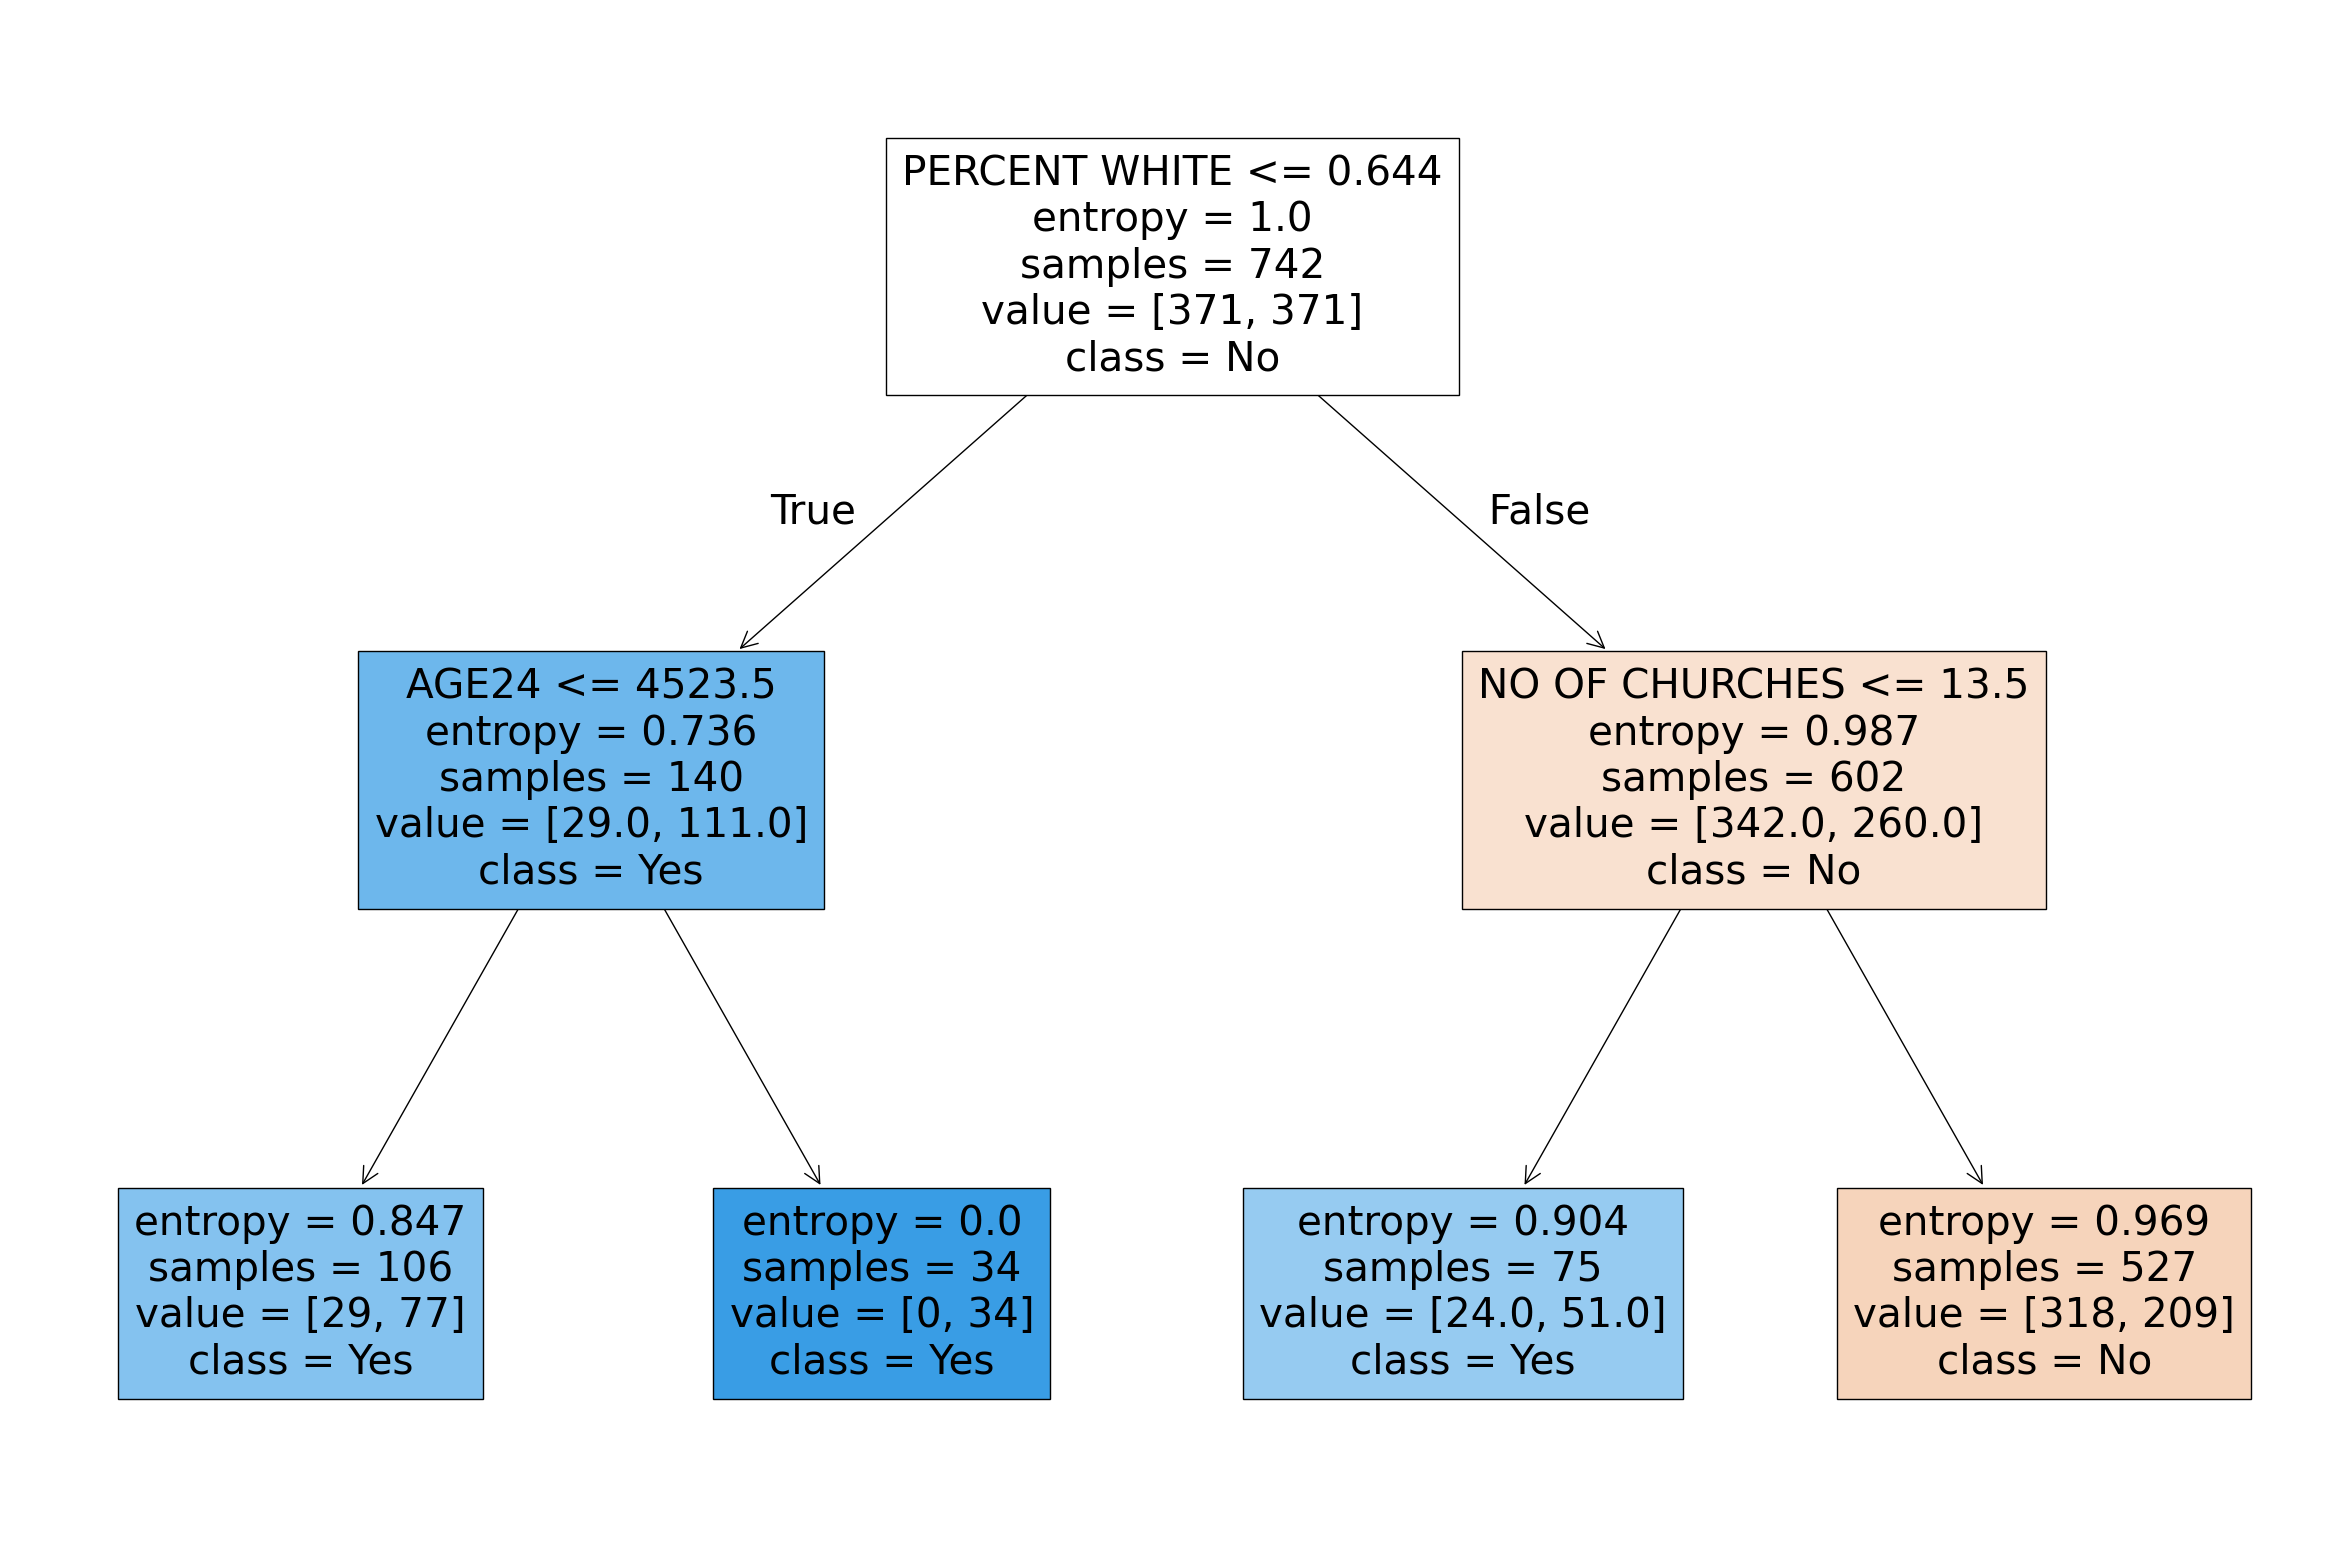

In [ ]:
# Plot the tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model_tree1,
               feature_names=list(gamingData.columns)[1:],
               class_names=['No','Yes'],
               filled=True)

In [ ]:
# Make predictions on training and testing data
prediction_on_train = model_tree1.predict(predictors_train)
prediction_on_test = model_tree1.predict(predictors_test)

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score
print(classification_report(target_train, prediction_on_train))

              precision    recall  f1-score   support

          No       0.60      0.86      0.71       371
         Yes       0.75      0.44      0.55       371

    accuracy                           0.65       742
   macro avg       0.68      0.65      0.63       742
weighted avg       0.68      0.65      0.63       742



In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.62      0.84      0.72       210
         Yes       0.68      0.40      0.50       177

    accuracy                           0.64       387
   macro avg       0.65      0.62      0.61       387
weighted avg       0.65      0.64      0.62       387



###Max Depth = 5

In [ ]:
# Build a decision tree model on training data with max_depth = 5
model_tree2 = DecisionTreeClassifier(criterion = "entropy",random_state = 1, max_depth = 5)
model_tree2.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=1)

In [ ]:
# Make predictions on training and testing data
prediction_on_train = model_tree2.predict(predictors_train)
prediction_on_test = model_tree2.predict(predictors_test)

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score
print(classification_report(target_train, prediction_on_train))

              precision    recall  f1-score   support

          No       0.70      0.70      0.70       371
         Yes       0.70      0.70      0.70       371

    accuracy                           0.70       742
   macro avg       0.70      0.70      0.70       742
weighted avg       0.70      0.70      0.70       742



In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.64      0.60      0.62       210
         Yes       0.56      0.60      0.58       177

    accuracy                           0.60       387
   macro avg       0.60      0.60      0.60       387
weighted avg       0.61      0.60      0.61       387



###Max Depth = 20

In [ ]:
# Build a decision tree model on training data with max_depth = 20
model_tree3 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 20)
model_tree3.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=1)

In [ ]:
# Make predictions on training and testing data
prediction_on_train = model_tree3.predict(predictors_train)
prediction_on_test = model_tree3.predict(predictors_test)

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score
print(classification_report(target_train, prediction_on_train))

              precision    recall  f1-score   support

          No       0.99      1.00      0.99       371
         Yes       1.00      0.99      0.99       371

    accuracy                           0.99       742
   macro avg       0.99      0.99      0.99       742
weighted avg       0.99      0.99      0.99       742



In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.65      0.62      0.64       210
         Yes       0.57      0.60      0.59       177

    accuracy                           0.61       387
   macro avg       0.61      0.61      0.61       387
weighted avg       0.61      0.61      0.61       387



##Which model depicts overfitting, underfitting, and good generalization?

*   Max depth = 2 underfit both training and testing accuracy is too low and too simple meaning it oversimplifies relationships
*   Max depth = 5 good generalization both precision and recall and reasonably balanced
*   Max depth = 20  overfit, large gap between training and testing results therefore performs poorly



##K-Nearest Neighbor

In [ ]:
# Drop the target variable and put all the predictors in a new dataframe
predictors = gamingData.drop(['DEPENDENT VARIABLE'],axis=1)

In [ ]:
# Apply minmax normalization on predictors
min_max_scaler = preprocessing.MinMaxScaler()
predictors_normalized = pd.DataFrame(min_max_scaler.fit_transform(predictors))
predictors_normalized.columns = predictors.columns
predictors_normalized

,POPULATION,PCI,MEDIUM FAMILY INCOME,SIZE OF COUNTY,POPULATION DENSITY,PERCENT WHITE,PERCENT MALE,NO OF CHURCHES,POVERTY LEVEL,UNEMPLOYMENT RATE,AGE64,PERCENT FEMALE,AGE24,BALLOT TYPE_2,MSA_2
0,0.219510,0.254833,0.515754,0.172025,0.065506,0.744657,0.588112,0.172320,0.154176,0.116095,0.231919,0.403354,0.163967,0.0,0.0
1,0.011021,0.206712,0.250795,0.096676,0.005439,0.579995,0.576335,0.028494,0.462527,0.168865,0.010111,0.415302,0.013379,0.0,1.0
2,0.324387,0.475978,0.751969,0.109587,0.143953,0.847571,0.569268,0.242877,0.057816,0.063325,0.349952,0.422471,0.214344,0.0,0.0
3,0.004161,0.182896,0.348565,0.197302,0.001085,0.734366,0.621088,0.017639,0.293362,0.116095,0.005479,0.369899,0.001545,0.0,1.0
4,0.003507,0.342724,0.249413,0.391055,0.000433,0.929902,0.585756,0.029851,0.338330,0.010554,0.004464,0.405744,0.001479,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,0.293719,0.339528,0.354623,0.757765,0.021851,0.477081,0.593539,0.407056,0.528908,0.395778,0.309737,0.397849,0.223096,0.0,0.0
1283,0.043703,0.370174,0.497144,0.345865,0.006719,0.868154,0.657710,0.052917,0.248394,0.195251,0.059111,0.332746,0.025243,0.0,1.0
1284,0.606855,0.592582,0.864572,0.335250,0.098107,0.610869,0.610134,0.423338,0.152034,0.131926,0.724238,0.381013,0.476635,0.0,0.0
1285,0.126846,0.517320,0.610945,0.144869,0.044714,0.641743,0.589342,0.107191,0.269807,0.126649,0.136374,0.402106,0.173546,0.0,0.0


In [ ]:
# Partition the data
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors_normalized, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(900, 15) (387, 15) (900,) (387,)


In [ ]:
# Taking steps to balance the train data
# Combine predictors_train and target_train into a single DataFrame
combined_train_df = pd.concat([predictors_train, target_train], axis=1)

# Separate majority and minority classes
majority_df = combined_train_df[combined_train_df['DEPENDENT VARIABLE'] == 'No']
minority_df = combined_train_df[combined_train_df['DEPENDENT VARIABLE'] == 'Yes']
#print(len(majority_df), len(minority_df))
# Undersample the majority class randomly
undersampled_majority = majority_df.sample(n=int(1*len(minority_df)), random_state=55)

# Combine the undersampled majority class and the minority class
undersampled_data = pd.concat([undersampled_majority, minority_df])

# Shuffle the combined DataFrame to ensure randomness
balanced_data = undersampled_data.sample(frac=1, random_state=1)

# Split the balanced_data into predictors_train and target_train
predictors_train = balanced_data.drop(columns=['DEPENDENT VARIABLE'])
target_train = balanced_data['DEPENDENT VARIABLE']

In [ ]:
# Examine the porportion of target variable for training data set
print(target_train.value_counts(normalize=True))

DEPENDENT VARIABLE
No     0.5
Yes    0.5
Name: proportion, dtype: float64


In [ ]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

DEPENDENT VARIABLE
No     0.542636
Yes    0.457364
Name: proportion, dtype: float64


### K = 1

In [ ]:
# Build a K Nearest Neighbor model on training data with n_neighbors = 1
kmodel1 = KNeighborsClassifier(n_neighbors = 1)
kmodel1.fit(predictors_train, target_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
# Make predictions on training and testing data
prediction_on_train = kmodel1.predict(predictors_train)
prediction_on_test = kmodel1.predict(predictors_test)

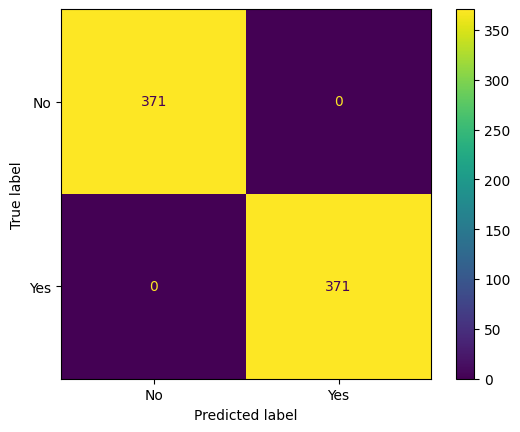

In [ ]:
# Examine the evaluation results on training data: confusion_matrix
cm = confusion_matrix(target_train, prediction_on_train)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=kmodel1.classes_).plot()

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score
print(classification_report(target_train , prediction_on_train ))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00       371
         Yes       1.00      1.00      1.00       371

    accuracy                           1.00       742
   macro avg       1.00      1.00      1.00       742
weighted avg       1.00      1.00      1.00       742



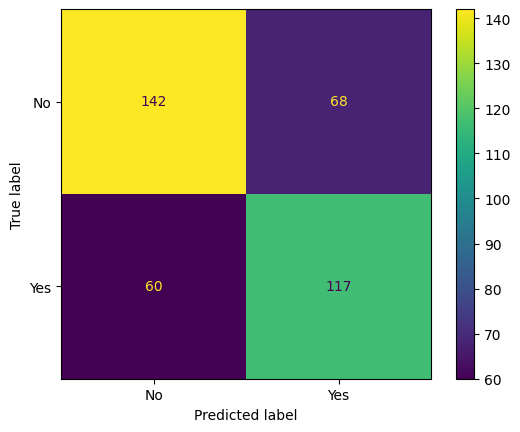

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=kmodel1.classes_).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.70      0.68      0.69       210
         Yes       0.63      0.66      0.65       177

    accuracy                           0.67       387
   macro avg       0.67      0.67      0.67       387
weighted avg       0.67      0.67      0.67       387



### K = 5

In [ ]:
# Build a K Nearest Neighbor model on training data with n_neighbors = 5
kmodel2 = KNeighborsClassifier(n_neighbors = 5)
kmodel2.fit(predictors_train, target_train)

KNeighborsClassifier()

In [ ]:
# Make predictions on training and testing data
prediction_on_train = kmodel2.predict(predictors_train)
prediction_on_test = kmodel2.predict(predictors_test)

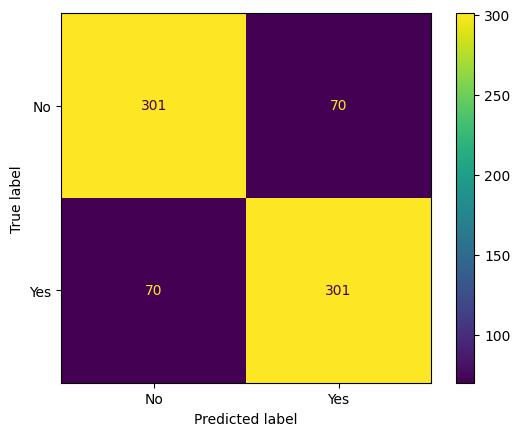

In [ ]:
# Examine the evaluation results on training data: confusion_matrix
cm = confusion_matrix(target_train, prediction_on_train)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=kmodel2.classes_).plot()

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score
print(classification_report(target_train, prediction_on_train))

              precision    recall  f1-score   support

          No       0.81      0.81      0.81       371
         Yes       0.81      0.81      0.81       371

    accuracy                           0.81       742
   macro avg       0.81      0.81      0.81       742
weighted avg       0.81      0.81      0.81       742



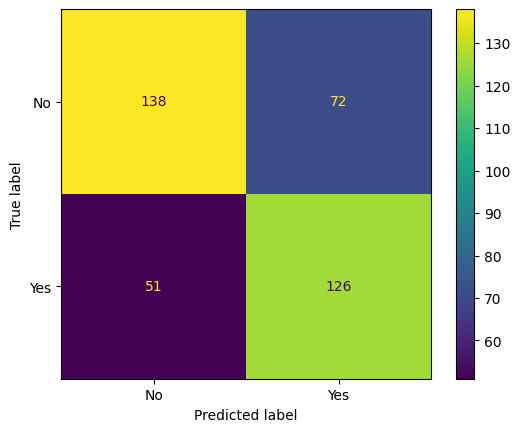

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=kmodel2.classes_).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.73      0.66      0.69       210
         Yes       0.64      0.71      0.67       177

    accuracy                           0.68       387
   macro avg       0.68      0.68      0.68       387
weighted avg       0.69      0.68      0.68       387



### K = 40

In [ ]:
# Build a K Nearest Neighbor model on training data with n_neighbors = 40
kmodel3 = KNeighborsClassifier(n_neighbors = 40)
kmodel3.fit(predictors_train, target_train)

KNeighborsClassifier(n_neighbors=40)

In [ ]:
# Make predictions on training and testing data
prediction_on_train = kmodel3.predict(predictors_train)
prediction_on_test = kmodel3.predict(predictors_test)

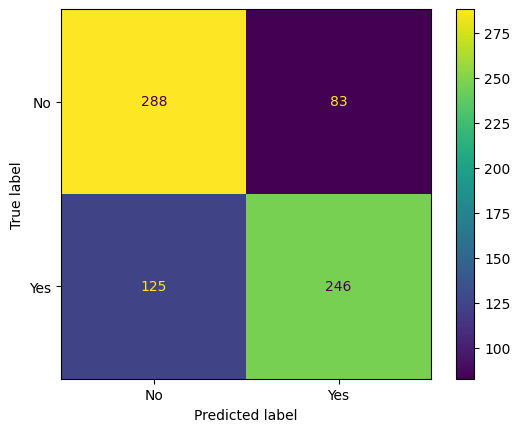

In [ ]:
# Examine the evaluation results on training data: confusion_matrix
cm = confusion_matrix(target_train, prediction_on_train)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=kmodel3.classes_).plot()

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score
print(classification_report(target_train , prediction_on_train ))

              precision    recall  f1-score   support

          No       0.70      0.78      0.73       371
         Yes       0.75      0.66      0.70       371

    accuracy                           0.72       742
   macro avg       0.72      0.72      0.72       742
weighted avg       0.72      0.72      0.72       742



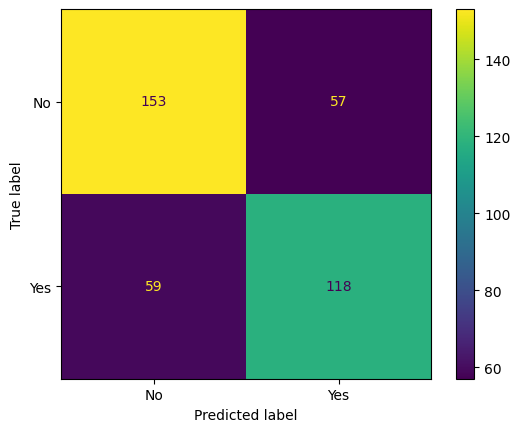

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=kmodel3.classes_).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.72      0.73      0.73       210
         Yes       0.67      0.67      0.67       177

    accuracy                           0.70       387
   macro avg       0.70      0.70      0.70       387
weighted avg       0.70      0.70      0.70       387



##Which model depicts overfitting, underfitting, and generalization?

*   k = 1 is overfit as it only captures results of one neighbor. Training data performs too well then testing data performs poorly which is an indicator of overfitting.
*   k = 5 is good generalization as it balanced and has a small gap between training and testing data. Precision and recall are balanced for yes and no.
*   k = 40 is an example of underfitting as it is too simple and doesn't capture the data enough.




##Naive Bayes Model

In [ ]:
# Build a Naive Bayes model on training data with default setting
model_NB = MultinomialNB()
model_NB.fit(predictors_train, target_train)

MultinomialNB()

In [ ]:
# Make predictions on testing data
prediction_on_test_NB = model_NB.predict(predictors_test)

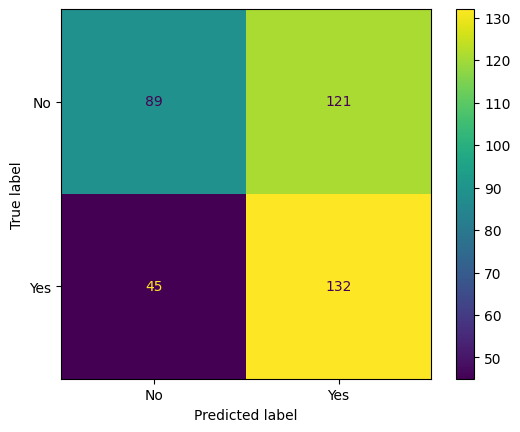

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm_NB = confusion_matrix(target_test, prediction_on_test_NB)
ConfusionMatrixDisplay(confusion_matrix=cm_NB, display_labels=model_NB.classes_).plot()
#plot_confusion_matrix(model, predictors_test, target_test, cmap=plt.cm.Blues, values_format='d')

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test_NB))

              precision    recall  f1-score   support

          No       0.66      0.42      0.52       210
         Yes       0.52      0.75      0.61       177

    accuracy                           0.57       387
   macro avg       0.59      0.58      0.57       387
weighted avg       0.60      0.57      0.56       387



###Can we improve this model's performance? Does it have any hyperparameters
Naive model assumes all features are independent. The model shows 57% overall accuracy likely because I failed to remove highly correlated variables. A hyperparameter would be tuning the laplace smoothing

###Compare the best performing DT, KNN, and NB. Choose your overall best performing model.
KNN (k=5)is the best performing model because it is balanced and has better overall accuracy for predicting voting outcomes.

#Evaluation

##Explain how your top model can be used to address the problem we started from: voting behavior?
The KNN model predicts a county's vote outcome by comparing it to nearby counties (distance similarity) and are also demographically, socially, and economically alike. For example, a county is most likely to vote "yes" if another county is similar in population, income, religous, or racial composition and also voted "yes".

##Discuss whether your model is practical for business.
This is practical becuase it allows related businesses/industries to be able to anticipate public response and react strategically.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/IS470Homework/DT,KNN,NBM.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470Homework/SantiagoStephanie.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 18 image(s).
[NbConvertApp] Writing 1495891 bytes to /content/drive/MyDrive/Colab Notebooks/IS470Homework/SantiagoStephanie.html
